In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [10]:
# Colormap
viridis5 = (253 / 255, 231 / 255, 37 / 255)
viridis4 = (94 / 255, 201 / 255, 98 / 255)
viridis3 = (33 / 255, 145 / 255, 140 / 255)
viridis2 = (59 / 255, 82 / 255, 139 / 255)
viridis1 = (68 / 255, 1 / 255, 84 / 255)
R1 = np.linspace(viridis1[0], viridis2[0], 25)
G1 = np.linspace(viridis1[1], viridis2[1], 25)
B1 = np.linspace(viridis1[2], viridis2[2], 25)
R2 = np.linspace(viridis2[0], viridis3[0], 25)
G2 = np.linspace(viridis2[1], viridis3[1], 25)
B2 = np.linspace(viridis2[2], viridis3[2], 25)
R3 = np.linspace(viridis3[0], viridis4[0], 25)
G3 = np.linspace(viridis3[1], viridis4[1], 25)
B3 = np.linspace(viridis3[2], viridis4[2], 25)
R4 = np.linspace(viridis4[0], viridis5[0], 26)
G4 = np.linspace(viridis4[1], viridis5[1], 26)
B4 = np.linspace(viridis4[2], viridis5[2], 26)
R = np.concatenate((R1, R2, R3, R4), axis=None)
G = np.concatenate((G1, G2, G3, G4), axis=None)
B = np.concatenate((B1, B2, B3, B4), axis=None)
viridis = np.array([R, G, B]).T  # 101x3 array with RGB values for each of the 101 colors in the viridis colormap


In [11]:
def structureData(labels, predictions):
    """Takes in labels and predictions dataframes and structures them for plotting"""

    frame = {"CellType":labels["0"],"first_prob":predictions["0"]}
    data = pd.DataFrame(frame)
    data['CellType'].mask(data['CellType'] == 'oRG', 'oRG/Astroglia', inplace=True)
    data['CellType'].mask(data['CellType'] == 'Astroglia', 'oRG/Astroglia', inplace=True)
    data['CellType'].mask(data['CellType'] == 'CPNs', 'Immature CPNs', inplace=True)
    data['first_prob'].mask(data['first_prob'] == 'oRG', 'oRG/Astroglia', inplace=True)
    data['first_prob'].mask(data['first_prob'] == 'Astroglia', 'oRG/Astroglia', inplace=True)
    data['first_prob'].mask(data['first_prob'] == 'CPNs', 'Immature CPNs', inplace=True)

    categorical_type = np.unique(data["CellType"])
    predicted_type = np.unique(data["first_prob"])

    rows = list(categorical_type)
    columns = list(predicted_type)

    df = pd.DataFrame(columns=columns, index=rows)

    for celltype in rows:
        dataset = data[data["CellType"] == celltype]
        countshistogram = dataset['first_prob'].value_counts()
        listofvalues = []
        for cell in columns:
            try:
                listofvalues.append(countshistogram[cell])
            except:
                listofvalues.append(0)
        llista = listofvalues / sum(listofvalues)
        llista = llista * 100
        df.loc[celltype] = llista

    for cell in columns:
        df[cell] = pd.to_numeric(df[cell])

    df = df[df.index.isin(df.columns)]  # only keep rows that are in columns

    # data = dataframe containing cell type counts for ground truth and predicted data
    # df = dataframe containing correlation percent between ground truth and predicted for each cell type
    return data, df

In [12]:
def setupFigure(title):
    """Sets up figure and returns panels for correlation matrix, colorbar, and two histograms"""
    figureWidth, figureHeight = 5, 5  # inches
    plt.figure(figsize=(figureWidth, figureHeight))
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')

    # main panel (correlation matrix)
    panelMainWidth, panelMainHeight = 2, 2  # inches
    panel_corr = plt.axes([1.6 / figureWidth, 1.6 / figureHeight, panelMainWidth / figureWidth,
                           panelMainHeight / figureHeight])  # left, bottom, width, height

    # panel_cbar (colorbar)
    panel_cbarWidth, panel_cbarHeight = 0.2, 1.2
    panel_cbar = plt.axes(
        [0.1 / figureWidth, 0.1 / figureHeight, panel_cbarWidth / figureWidth, panel_cbarHeight / figureHeight])

    # panel_top (histogram for df columns/predicted counts)
    panel_topWidth, panel_topHeight = 2, 0.4
    panel_top = plt.axes([1.6 / figureWidth, 3.65 / figureHeight, panel_topWidth / figureWidth,
                          panel_topHeight / figureHeight])  # left, bottom, width, height

    # panel_right (histogram for df rows/groundTruth counts)
    panel_rightWidth, panel_rightHeight = 0.4, 2
    panel_right = plt.axes([3.65 / figureWidth, 1.6 / figureHeight, panel_rightWidth / figureWidth,
                            panel_rightHeight / figureHeight])  # left, bottom, width, height

    return panel_corr, panel_cbar, panel_top, panel_right

In [13]:
def plotCorrelationMatrix(df, panel_corr, panel_cbar, xlabel='Predicted', ylabel='Ground Truth'):
    """Takes a pandas dataframe as input and plots a correlation matrix. Returns the order of the columns in the plot"""

    # format colorbar
    panel_cbar.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False, right=True, labelright=True,
                           top=False, labeltop=False, labelsize=8, pad=1)
    panel_cbar.set_xlim(0, 1)
    panel_cbar.set_ylim(0, 20)
    panel_cbar.set_yticks([0, 5, 10, 15, 20], [0, 25, 50, 75, 100])  # set_yticks([positions], [labels])
    
    # plot colorbar
    for i in range(0, 21):
        panel_cbar.add_patch(mplpatches.Rectangle((0, i), 1, 1, facecolor=viridis[i*5], edgecolor='none'))

    # format correlation matrix panel
    panel_corr.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=8, labelrotation=90)
    panel_corr.tick_params(axis='y', left=True, labelleft=True, labelsize=8, )
    ticks = list(range(len(df.columns)))    # [position for each tick mark]
    for i in ticks:     # center tick marks/labels
        tick = i + 0.5
        ticks[ticks.index(i)] = tick
    panel_corr.set_xticks(ticks, labels=df.columns)
    panel_corr.set_yticks(ticks, labels=df.index)
    panel_corr.set_xlim(0, len(df.columns))
    panel_corr.set_ylim(0, len(df.columns))
    panel_corr.set_xlabel(xlabel)
    panel_corr.set_ylabel(ylabel)

    # plot correlation matrix
    # df values as rectangles with color corresponding to value
    for i in range(0, len(df.columns)):
        for j in range(0, len(df.columns)):
            color = viridis[round(df.iloc[i, j])]
            panel_corr.add_patch(mplpatches.Rectangle((i, j), 1, 1, facecolor=color, edgecolor='none'))

    return 


In [14]:
def plotHistogram(data, panel_top, panel_right, plotOrder):
    """Takes data as pandas dataframe and plots as a histogram aligned to the correlation matrix plot"""
    counts_predicted = data.first_prob.value_counts()   # counts for each predicted cell type as pd series
    counts_groundTruth = data.CellType.value_counts()   # counts for each ground truth cell type as pd series
    counts_predicted = counts_predicted.reindex(plotOrder)  # sort by plotOrder
    counts_groundTruth = counts_groundTruth.reindex(plotOrder)
    maxCount = max(counts_predicted.max(), counts_groundTruth.max())   # max count of cells of any type

    # format top histogram (horizontal layout)
    panel_top.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False, right=False, labelright=False, top=False, labeltop=False)
    panel_top.set_xlim(0, len(df.columns))
    panel_top.set_ylim(0, maxCount)
    #panel_top.set_ylim(0, np.log2(maxCount + 1))
    panel_top.spines['top'].set_visible(False)  # remove panel borders
    panel_top.spines['right'].set_visible(False)
    panel_top.spines['bottom'].set_visible(True)
    panel_top.spines['left'].set_visible(False)

    # plot top histogram
    #xvalues = counts_predicted.index  # cell types
    yvalues = counts_predicted.values  # number of cells of each type (height of bars)
    bins = np.arange(0, len(counts_predicted), 1)   # bins = [x position values of histogram bars]
    for i in range(0, len(yvalues)):
        left = bins[i] + 0.25
        bottom = 0
        width = 0.5
        height = yvalues[i]
        #height = np.log2(yvalues[i] + 1)
        panel_top.add_patch(mplpatches.Rectangle((left, bottom), width, height, facecolor='grey', edgecolor='black'))
        panel_top.text((left + .25), height, str(yvalues[i]), ha='center', va='bottom', fontsize=8)

    # format right histogram (vertical layout)
    panel_right.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False, right=False, labelright=False, top=False, labeltop=False)
    panel_right.set_xlim(0, maxCount)
    panel_right.set_ylim(0, len(df.columns))
    panel_right.spines['top'].set_visible(False)  # remove panel borders
    panel_right.spines['right'].set_visible(False)
    panel_right.spines['bottom'].set_visible(False)
    panel_right.spines['left'].set_visible(True)

    # plot right histogram
    #yvalues = counts_groundTruth.index  # cell types
    xvalues = counts_groundTruth.values  # number of cells of each type (height of bars)
    bins = np.arange(0, len(counts_groundTruth), 1)   # bins = [y position values of histogram bars]
    for i in range(0, len(xvalues)):
        left = 0
        bottom = bins[i] + 0.25 # (y position of bars)
        width = xvalues[i] #(height of bars)
        height = 0.5 # (width of bars)
        panel_right.add_patch(mplpatches.Rectangle((left, bottom), width, height, facecolor='grey', edgecolor='black'))
        panel_right.text(width, (bottom + 0.25), str(xvalues[i]), ha='left', va='center', fontsize=8)

    return

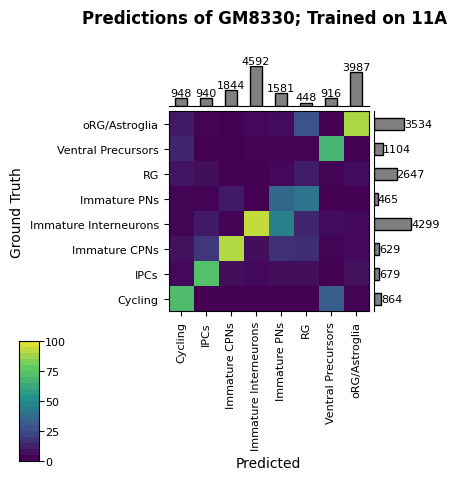

In [15]:
# read in data
labels = pd.read_csv("/Users/macadmin/.aws/smedor/interspecies_labeltransfer/results/example/labels.csv")
predictions = pd.read_csv("/Users/macadmin/.aws/smedor/interspecies_labeltransfer/results/example/predictions.csv")

# structure data for plotting
data, df = structureData(labels, predictions)

# setup figure panels
title = "Predictions of GM8330; Trained on 11A"
panel_corr, panel_cbar, panel_top, panel_right = setupFigure(title)

# plot correlation matrix with predictions on x-axis and labels on y-axis
plotCorrelationMatrix(df, panel_corr, panel_cbar)  # optional: (xlabel='', ylabel='')

# plot histograms of cell type counts for predicted (top panel) and ground truth (right panel_corr)
plotOrder = df.columns # plotOrder = list of indexes (cell types) in the order they are plotted on the correlation matrix panel
plotHistogram(data, panel_top, panel_right, plotOrder)

# show/save figure
plt.show()
#plt.savefig("example.png", dpi=300)